# 1. Download the Dataset
To build this model, we are using Mandaley Dataset.

In [1]:
# Download Rice Leaf Disease dataset from Mendeley Data (Version 2)
# Direct public-files URL — no login required
!wget -q --show-progress -O rice_disease_data.zip "https://data.mendeley.com/public-files/datasets/zfwkkdj6dk/files/077388af-3fc5-47fe-9017-8ff3705642f5/file_downloaded"

#Unzip the dataset
!unzip -q rice_disease_data.zip -d /content/rice_dataset
print("Download and extraction complete.")

rice_disease_data.z 100%[===================>]   8.08G  24.5MB/s    in 5m 33s  
Download and extraction complete.


# 2. Import Necessary Libraries

In [2]:
import os
import gc
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid

from PIL import Image

print("All libraries imported successfully.")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

All libraries imported successfully.
PyTorch 2.11.0+cu128 | CUDA: True


In [3]:
os.environ["PYTHON_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# 3. Dataset overview

In [5]:
EXTRACT_PATH = "/content/rice_dataset"

outer_folder = [
    d for d in os.listdir(EXTRACT_PATH)
    if os.path.isdir(os.path.join(EXTRACT_PATH, d))
][0]
print(f"Outer folder: {outer_folder}")

ds_train = os.path.join(EXTRACT_PATH, outer_folder, "Rice disease leaf", "Train")
ds_test = os.path.join(EXTRACT_PATH, outer_folder, "Rice disease leaf", "Test")

print(f"Train: {ds_train}")
print(f"Test: {ds_test}")
print(f"Train exists: {os.path.exists(ds_train)}")
print(f"Test exists: {os.path.exists(ds_test)}")



Outer folder: Rice leaf disease classification
Train: /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Train
Test: /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test
Train exists: True
Test exists: True


## 3.1 Train Dataset Overview

In [6]:
train_folder_path = ds_train
train_data_list = sorted(os.listdir(train_folder_path))
print(f"Found {len(train_data_list)} disase classes: ")
train_data_list

Found 10 disase classes: 


['bacterial_leaf_blight',
 'brown_spot',
 'healthy',
 'leaf_blast',
 'leaf_scald',
 'narrow_brown_spot',
 'neck_blast',
 'rice_hispa',
 'sheath_blight',
 'tungro']

In [7]:
for cls in train_data_list:
    n = len(os.listdir(os.path.join(train_folder_path, cls)))
    print(f"  {cls:<55} : {n:,}")

  bacterial_leaf_blight                                   : 1,386
  brown_spot                                              : 1,480
  healthy                                                 : 1,491
  leaf_blast                                              : 1,801
  leaf_scald                                              : 1,670
  narrow_brown_spot                                       : 1,416
  neck_blast                                              : 1,000
  rice_hispa                                              : 1,461
  sheath_blight                                           : 1,578
  tungro                                                  : 1,740


# 4. Transforming, Preparing and Splitting the Dataset

The dataset has no validation data folder, so we need to create a validation data by performing an <b>80/20</b> random split from the training dataset

In [8]:
train_data_transform = tt.Compose([
    tt.Resize(256),
        tt.RandomCrop(224),
        tt.RandomHorizontalFlip(),
        tt.RandomVerticalFlip(),
        tt.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        tt.ToTensor(),
        tt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_data_transform = tt.Compose([
    tt.Resize(256),
    tt.CenterCrop(224),
    tt.ToTensor(),
    tt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load full dataset twice — one per transform
full_train_dataset = ImageFolder(ds_train, transform=train_data_transform)
full_valid_dataset = ImageFolder(ds_train, transform=valid_data_transform)

# 80/20 split with fixed seed for reproducibility
n_total = len(full_train_dataset)
n_valid = int(0.2 * n_total)
n_train = n_total - n_valid

generator = torch.Generator().manual_seed(42)
split_subsets = torch.utils.data.random_split(range(n_total), [n_train, n_valid], generator=generator)
train_indices = split_subsets[0].indices
valid_indices = split_subsets[1].indices

train_set = torch.utils.data.Subset(full_train_dataset, train_indices)
valid_set = torch.utils.data.Subset(full_valid_dataset, valid_indices)

print(f"Total images      : {n_total:,}")
print(f"Training images   : {n_train:,}  ({n_train/n_total*100:.0f}%)")
print(f"Validation images : {n_valid:,}  ({n_valid/n_total*100:.0f}%)")
print(f"Classes           : {len(full_train_dataset.classes)}")
print(f"Class names       : {full_train_dataset.classes}")

Total images      : 15,023
Training images   : 12,019  (80%)
Validation images : 3,004  (20%)
Classes           : 10
Class names       : ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot', 'neck_blast', 'rice_hispa', 'sheath_blight', 'tungro']


# 5. Visualizing Sample Images

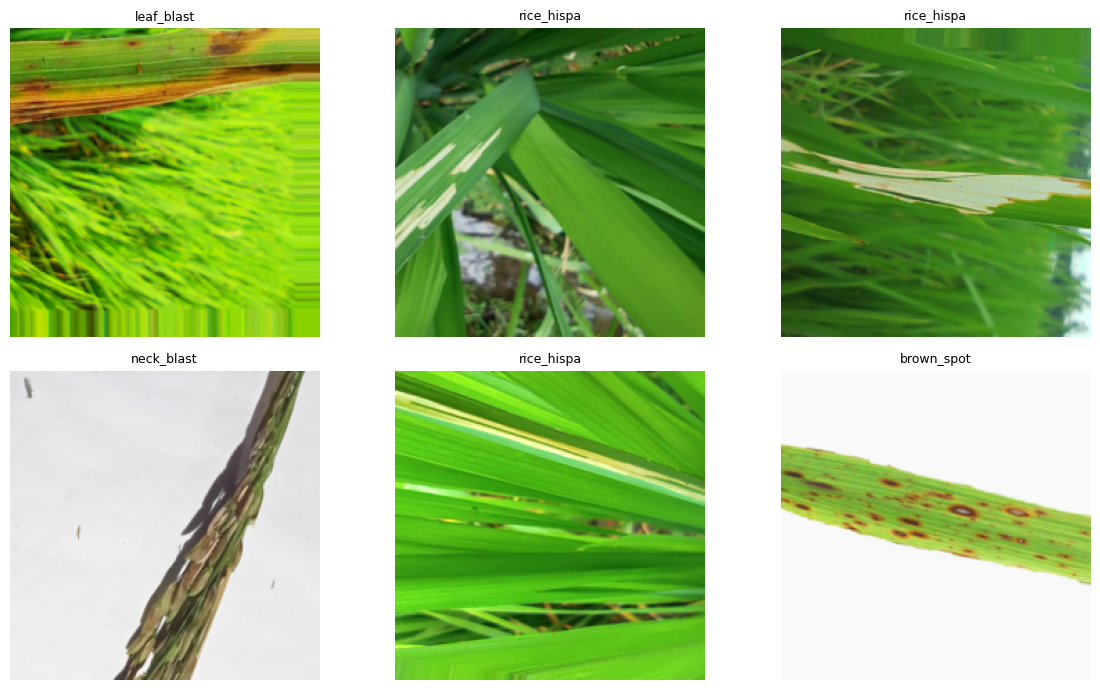

In [9]:
def showImages(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return (tensor * s + m).clamp(0, 1)

def show_sample(dataset, indices, ncols=3):
    # dataset must be a Subset — access underlying dataset for .classes
    base = dataset.dataset if hasattr(dataset, 'dataset') else dataset
    nrows = (len(indices) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        ax.imshow(showImages(img).permute(1, 2, 0))
        ax.set_title(base.classes[label], fontsize=9, wrap=True)
        ax.axis('off')
    for ax in axes[len(indices):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample(train_set, [0, 50, 100, 200, 300, 400])

# 6. Creating DataLoaders

In [10]:
BATCH_SIZE  = 128
NUM_WORKERS = 4
PREFETCH    = 2

train_dataloader = DataLoader(
    train_set,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    prefetch_factor    = PREFETCH,
    persistent_workers = True,
)
valid_dataloader = DataLoader(
    valid_set,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = True,
    prefetch_factor    = PREFETCH,
    persistent_workers = True,
)

print(f"Train batches : {len(train_dataloader):,}")
print(f"Valid batches : {len(valid_dataloader):,}")
print(f"Batch size    : {BATCH_SIZE}")

Train batches : 94
Valid batches : 24
Batch size    : 128


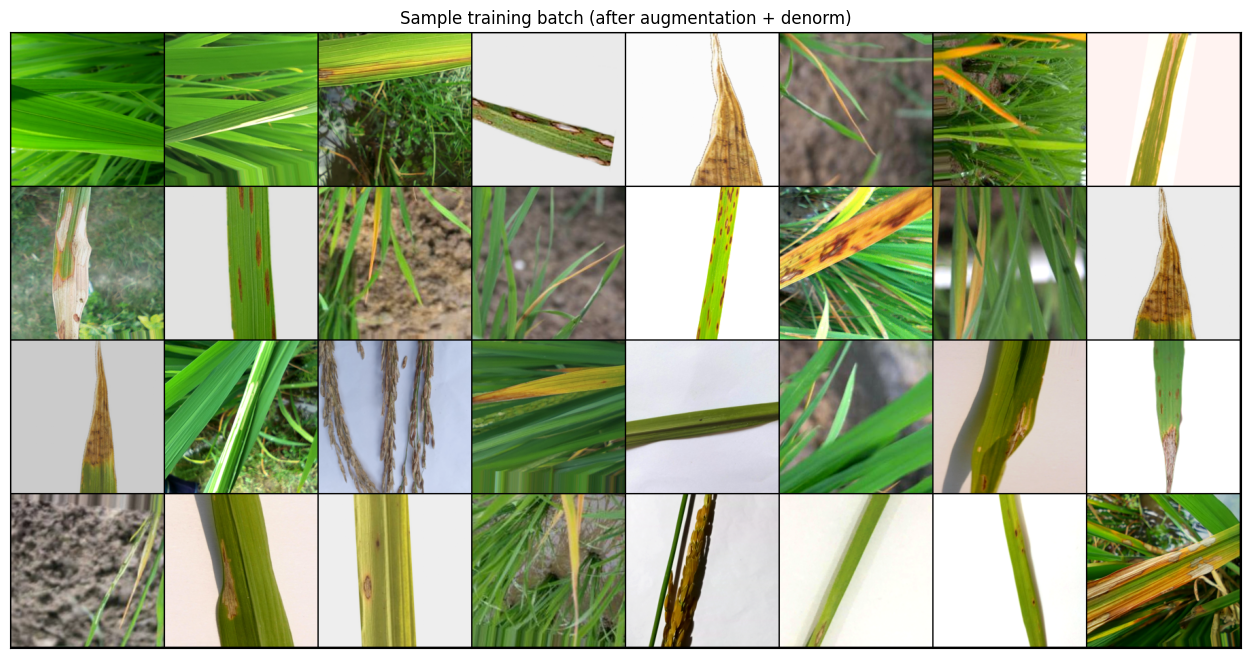

In [11]:
def show_batch_img(dl):
    images, _ = next(iter(dl))
    images = torch.stack([showImages(img) for img in images])
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(images[:32], nrow=8).permute(1, 2, 0))
    plt.title("Sample training batch (after augmentation + denorm)", fontsize=12)
    plt.show()

show_batch_img(train_dataloader)

# 7. Device Setup

In [12]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)
    def __len__(self):
        return len(self.dl)

device = get_default_device()
print(f"Using device: {device}")

train_dataloader = DeviceDataLoader(train_dataloader, device)
valid_dataloader = DeviceDataLoader(valid_dataloader, device)

Using device: cuda


# 8. Building the CNN Model

In [13]:
class RiceDiseaseDetection(nn.Module):
    def training_step(self, batch):
        images, label = batch
        out  = self(images)
        loss = F.cross_entropy(out, label)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out  = self(images)
        loss = F.cross_entropy(out, labels)
        acc  = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        epoch_loss = torch.stack([x['val_loss'] for x in outputs]).mean()
        epoch_acc  = torch.stack([x['val_acc']  for x in outputs]).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print(f"Epoch [{epoch:>3}]  "
              f"train_loss: {result['train_loss']:.4f}  "
              f"val_loss: {result['val_loss']:.4f}  "
              f"val_acc: {result['val_acc']*100:.2f}%")

In [14]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

scaler = torch.cuda.amp.GradScaler()

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history   = []
    optimizer = opt_func(model.parameters(), lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader), epochs=epochs
    )
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            with torch.cuda.amp.autocast():
                loss = model.training_step(batch)
            train_losses.append(loss.detach())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch + 1, result)
        history.append(result)
        gc.collect()
    return history

In [15]:
FLATTEN_SIZE = 50176   # 256 × 14 × 14 for 224×224 input

class CNN(RiceDiseaseDetection):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32,  32,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64,  64,  3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )
        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(FLATTEN_SIZE, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        assert x.numel() // x.shape[0] == FLATTEN_SIZE, \
            f"Flatten mismatch: expected {FLATTEN_SIZE}, got {x.numel()//x.shape[0]}"
        x = x.view(x.size(0), -1)
        return self.dense_layers(x)

model = to_device(CNN(len(full_train_dataset.classes)), device)

if hasattr(torch, 'compile'):
    model = torch.compile(model)
    print("torch.compile applied ✅")
else:
    print("torch.compile not available — using eager mode")

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")
print(f"Classes         : {len(full_train_dataset.classes)}")
print(f"Device          : {device}")

torch.compile applied ✅
Total parameters: 52,565,674
Classes         : 10
Device          : cuda


In [16]:
torch.cuda.empty_cache()
for images, labels in train_dataloader:
    print(f"images shape : {images.shape}")
    print(f"device       : {images.device}")
    pred = model(images)
    print(f"pred shape   : {pred.shape}")
    torch.cuda.empty_cache()
    break

images shape : torch.Size([128, 3, 224, 224])
device       : cuda:0


W0828 01:05:36.997000 7451 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


pred shape   : torch.Size([128, 10])


In [17]:
history = [evaluate(model, valid_dataloader)]
print("Initial (random weights):", history)

Initial (random weights): [{'val_loss': 2.3019227981567383, 'val_acc': 0.09229600429534912}]


# 9. Training the Model 

In [18]:
%%time
history = []
history += fit(8, 1e-3, model, train_dataloader, valid_dataloader)

Epoch [  1]  train_loss: 1.2043  val_loss: 1.6410  val_acc: 55.25%
Epoch [  2]  train_loss: 1.1697  val_loss: 1.1413  val_acc: 65.89%
Epoch [  3]  train_loss: 0.9331  val_loss: 0.7000  val_acc: 77.92%
Epoch [  4]  train_loss: 0.6757  val_loss: 2.0915  val_acc: 65.08%
Epoch [  5]  train_loss: 0.5741  val_loss: 0.3926  val_acc: 86.90%
Epoch [  6]  train_loss: 0.4390  val_loss: 0.2551  val_acc: 90.53%
Epoch [  7]  train_loss: 0.3403  val_loss: 0.2167  val_acc: 92.05%
Epoch [  8]  train_loss: 0.3073  val_loss: 0.2043  val_acc: 92.47%
CPU times: user 2min 29s, sys: 21.7 s, total: 2min 51s
Wall time: 55min 36s


In [19]:
%%time
history += fit(8, 1e-4, model, train_dataloader, valid_dataloader)

Epoch [  1]  train_loss: 0.2941  val_loss: 0.1978  val_acc: 92.86%
Epoch [  2]  train_loss: 0.3014  val_loss: 0.2229  val_acc: 92.17%
Epoch [  3]  train_loss: 0.2998  val_loss: 0.1986  val_acc: 92.76%
Epoch [  4]  train_loss: 0.2755  val_loss: 0.1729  val_acc: 94.20%
Epoch [  5]  train_loss: 0.2486  val_loss: 0.1516  val_acc: 94.79%
Epoch [  6]  train_loss: 0.2293  val_loss: 0.1337  val_acc: 95.44%
Epoch [  7]  train_loss: 0.2038  val_loss: 0.1253  val_acc: 95.63%
Epoch [  8]  train_loss: 0.1924  val_loss: 0.1228  val_acc: 95.63%
CPU times: user 2min 26s, sys: 21.8 s, total: 2min 47s
Wall time: 55min 25s


In [20]:
%%time
history += fit(4, 1e-5, model, train_dataloader, valid_dataloader)

Epoch [  1]  train_loss: 0.1925  val_loss: 0.1223  val_acc: 95.70%
Epoch [  2]  train_loss: 0.1872  val_loss: 0.1218  val_acc: 95.60%
Epoch [  3]  train_loss: 0.1801  val_loss: 0.1192  val_acc: 95.63%
Epoch [  4]  train_loss: 0.1895  val_loss: 0.1206  val_acc: 95.80%
CPU times: user 1min 14s, sys: 11 s, total: 1min 25s
Wall time: 27min 37s


# 10. Saving and Loading the Model

In [21]:
import pathlib

MODEL_DIR  = pathlib.Path('/content/models')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'Rice_Disease_Detection_Model.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes':      len(full_train_dataset.classes),
    'class_names':      full_train_dataset.classes,
}, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: /content/models/Rice_Disease_Detection_Model.pth


In [22]:
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

# torch.compile wraps state dict keys with '_orig_mod.' prefix — strip it
state_dict = checkpoint['model_state_dict']
state_dict = {
    k.replace('_orig_mod.', ''): v
    for k, v in state_dict.items()
}

model_loaded = CNN(checkpoint['num_classes'])
model_loaded.load_state_dict(state_dict)
model_loaded = to_device(model_loaded, device)
model_loaded.eval()

CLASS_NAMES = checkpoint['class_names']
print(f"Model loaded successfully.")
print(f"Classes ({checkpoint['num_classes']}): {CLASS_NAMES}")

Model loaded successfully.
Classes (10): ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot', 'neck_blast', 'rice_hispa', 'sheath_blight', 'tungro']


# 11. Plotting Accuracy and Loss

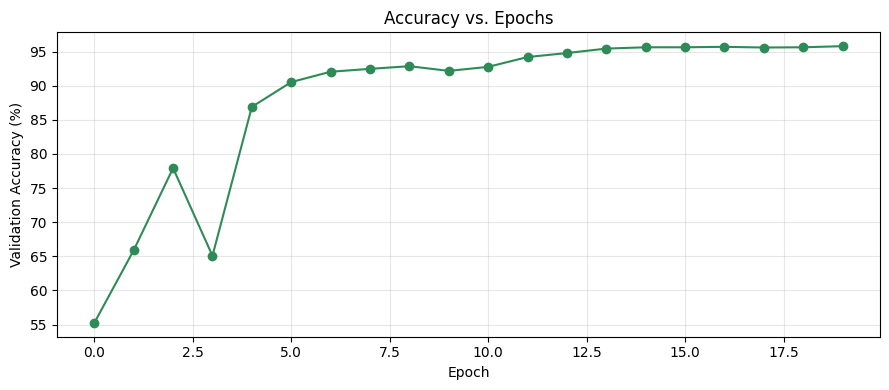

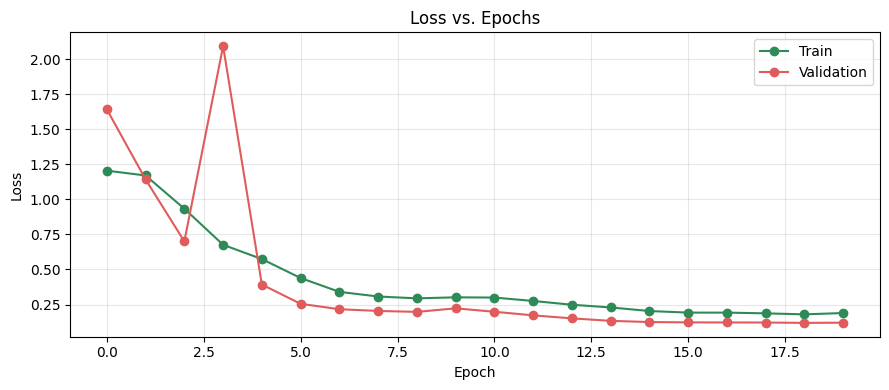

In [23]:
def plot_accuracies(history):
    accs = [x['val_acc'] * 100 for x in history]
    plt.figure(figsize=(9, 4))
    plt.plot(accs, '-o', color='#2E8B57')
    plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
    plt.title('Accuracy vs. Epochs'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses   = [x['val_loss']       for x in history]
    plt.figure(figsize=(9, 4))
    plt.plot(train_losses, '-o', label='Train',      color='#2E8B57')
    plt.plot(val_losses,   '-o', label='Validation', color='#e05c5c')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss vs. Epochs'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_accuracies(history)
plot_losses(history)

# 12. Predicting Rice Diseases with Validation Samples 

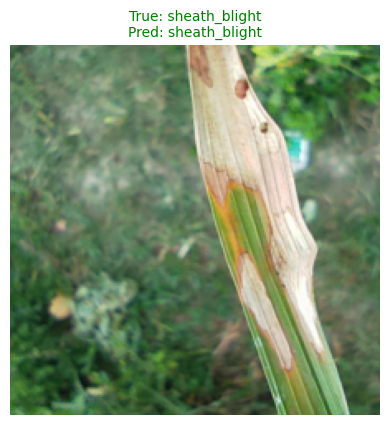

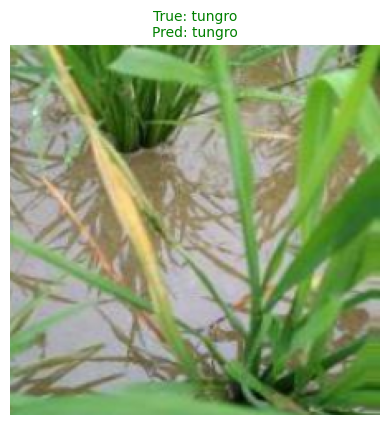

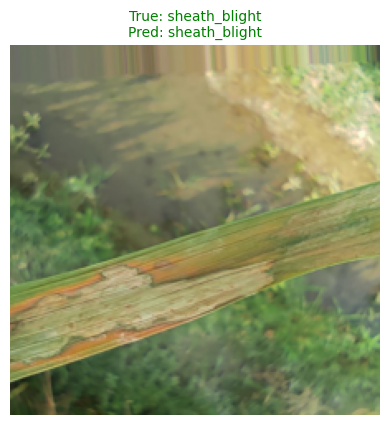

In [24]:
model = to_device(model_loaded, device)

def predict_image(img_tensor, model):
    xb  = to_device(img_tensor.unsqueeze(0), device)
    yb  = model(xb)
    _, pred = torch.max(yb, dim=1)
    return CLASS_NAMES[pred[0].item()]

def show_image_prediction(img_tensor, label):
    display_img = showImages(img_tensor).permute(1, 2, 0).numpy()
    plt.imshow(display_img)
    true  = CLASS_NAMES[label]
    pred  = predict_image(img_tensor, model)
    color = 'green' if true == pred else 'red'
    plt.title(f"True: {true}\nPred: {pred}", color=color, fontsize=10)
    plt.axis('off'); plt.show()

# Show a few samples from the validation split
for idx in [10, 50, 100]:
    show_image_prediction(*valid_set[idx])

# 13. Predicting Disease with Test Images 

In [25]:
_infer_tf = tt.Compose([
    tt.Resize(256),
    tt.CenterCrop(224),
    tt.ToTensor(),
    tt.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def single_prediction(image_path: str, show: bool = True):
    image      = Image.open(image_path).convert('RGB')
    input_data = _infer_tf(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_data)
    index = output.argmax(dim=1).item()

    predicted_class_name = CLASS_NAMES[index]

    if show:
        fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(10, 4))
        ax_img.imshow(image); ax_img.axis('off'); ax_img.set_title('Input Image')
        ax_txt.axis('off')
        ax_txt.text(0.05, 0.5, f'Predicted Disease:\n  {predicted_class_name}',
                    fontsize=14, transform=ax_txt.transAxes, color='#c0392b',
                    verticalalignment='center')
        plt.tight_layout(); plt.show()

    print(f"Predicted : {predicted_class_name}")
    return predicted_class_name

# 14. Sample Prediction on Test Images 

In [26]:
# Auto-discover one test image per class
test_images = []
for cls in sorted(os.listdir(ds_test)):
    cls_path = os.path.join(ds_test, cls)
    if os.path.isdir(cls_path):
        imgs = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        if imgs:
            test_images.append((cls, os.path.join(cls_path, imgs[0])))

print(f"Found {len(test_images)} test classes:")
for cls, path in test_images:
    print(f"  {cls} — {path}")

Found 10 test classes:
  Neck_Blast — /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test/Neck_Blast/neck blast (290).jpg
  Rice Hispa — /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test/Rice Hispa/rice hispa (84).jpg
  Sheath Blight — /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test/Sheath Blight/sheath blight (204).jpg
  bacterial leaf blight — /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test/bacterial leaf blight/bacterial leaf blight (39).JPG
  brown spot — /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test/brown spot/brown spot (28).jpg
  healthy — /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test/healthy/healthy (176).jpg
  leaf blast — /content/rice_dataset/Rice leaf disease classification/Rice disease leaf/Test/leaf blast/leaf blast (110).jpg
  leaf scald — /content/rice_dataset/Rice leaf disease classification/Ri


--- True class: Neck_Blast ---


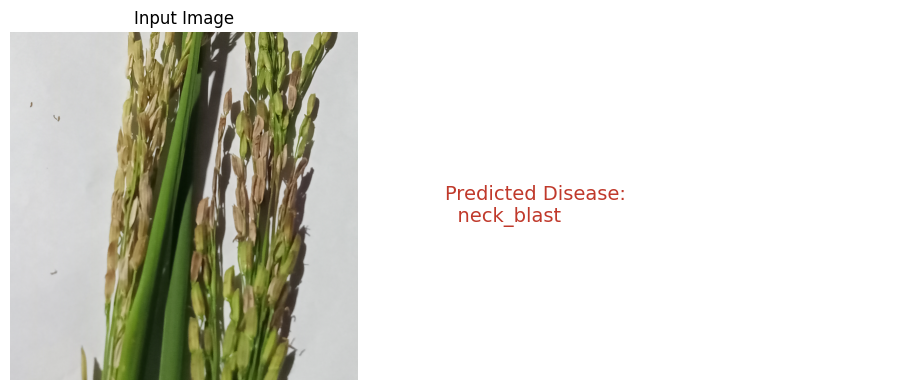

Predicted : neck_blast

--- True class: Rice Hispa ---


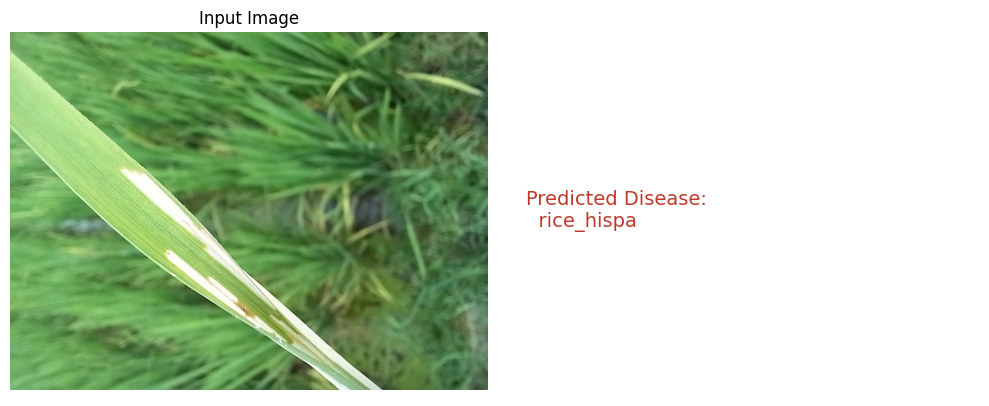

Predicted : rice_hispa

--- True class: Sheath Blight ---


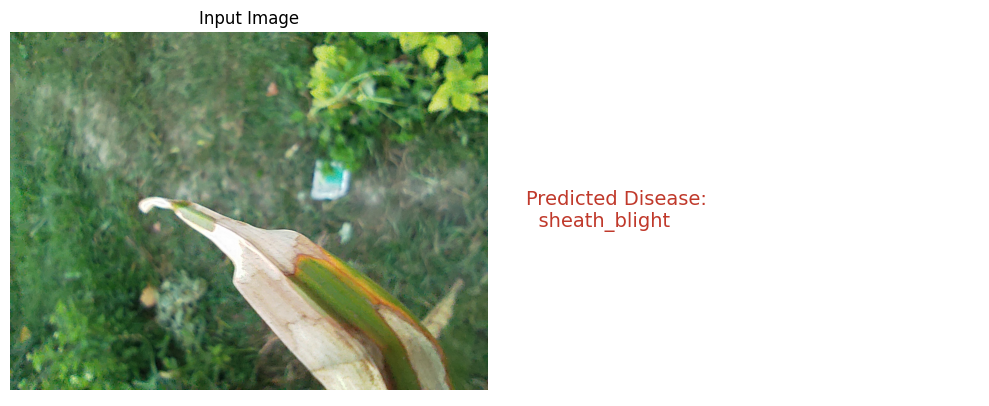

Predicted : sheath_blight

--- True class: bacterial leaf blight ---


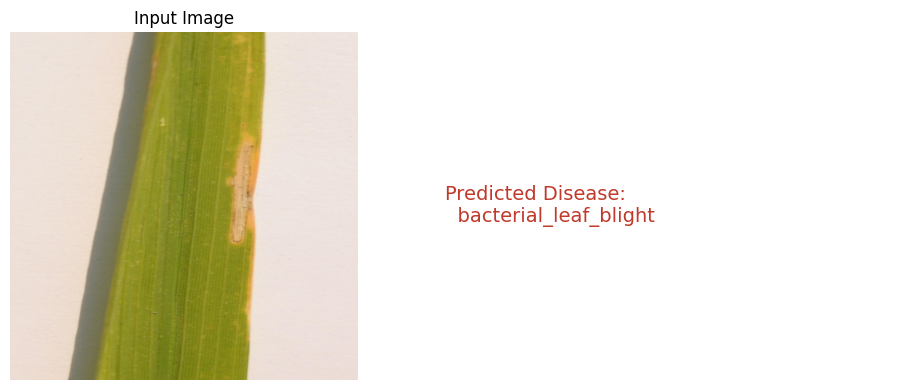

Predicted : bacterial_leaf_blight

--- True class: brown spot ---


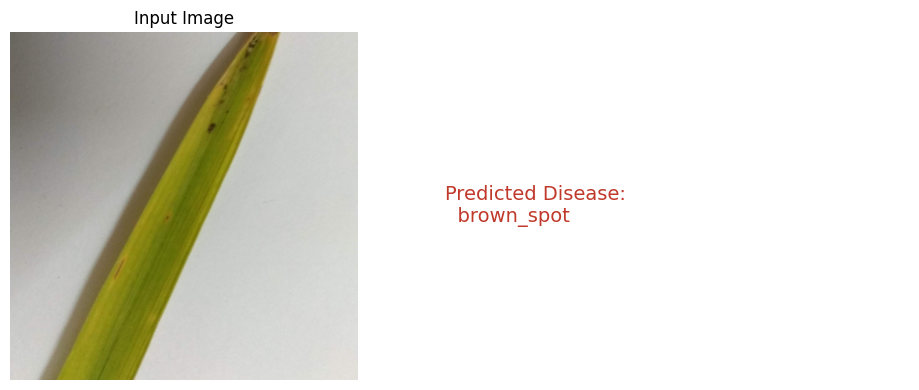

Predicted : brown_spot

--- True class: healthy ---


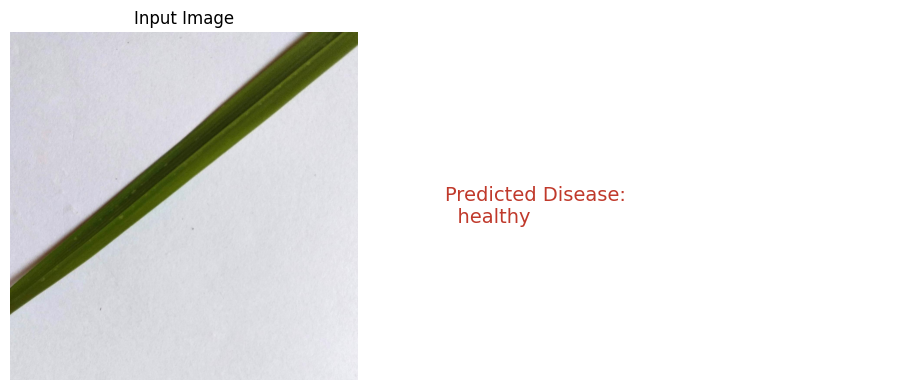

Predicted : healthy

--- True class: leaf blast ---


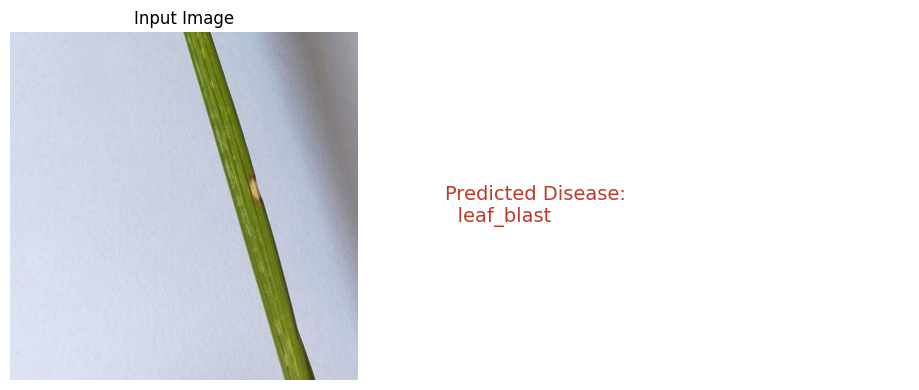

Predicted : leaf_blast

--- True class: leaf scald ---


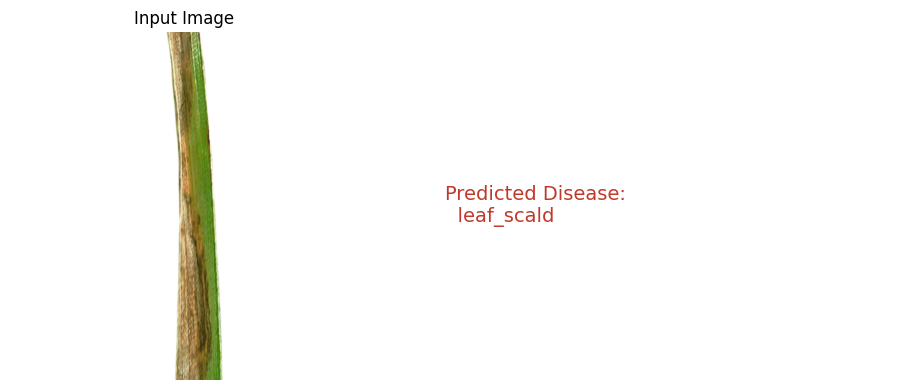

Predicted : leaf_scald

--- True class: narrow brown spot ---


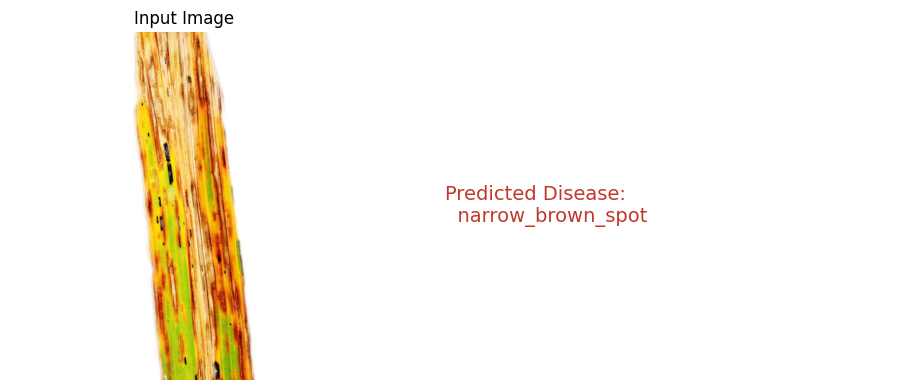

Predicted : narrow_brown_spot

--- True class: tungro ---


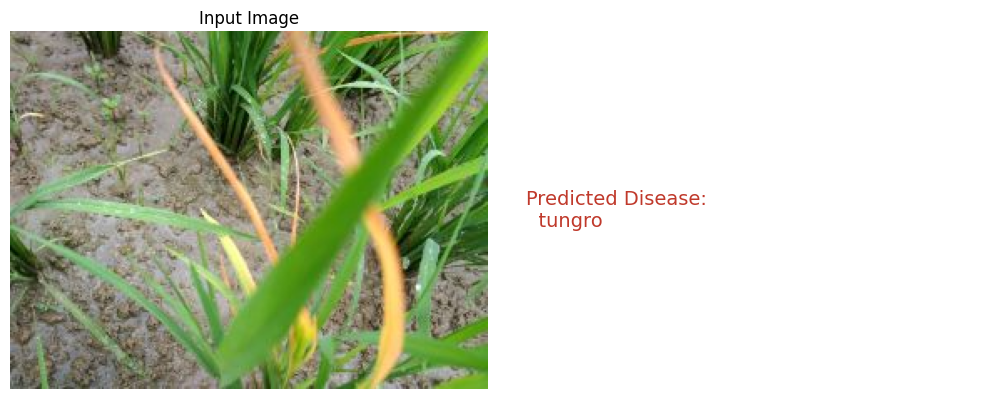

Predicted : tungro


In [27]:
# Run prediction on one image from each test class
for cls, img_path in test_images:
    print(f"\n--- True class: {cls} ---")
    single_prediction(img_path)